# Marco teórico

Las caracteristicas del flujo de fluidos en la nanoescala difieren notablemente de sus contrapartes macroescalar. En particular, a esta escala la clásica condición de no deslizamiento deja de ser válida y es  común observar un "deslizamiento" interfacial, en el que la velocidad del fluido difiera a la velocidad de la pared. En base a esto, se define la *velocidad de deslizamiento* $v_s$, correspondiente a la velocidad del fluido en la interfase sólido-fluido. Normalmente, este fenómeno se caracteriza mediante la *condición de deslizamiento de Navier*, la cual establece que la velocidad de deslizamiento es proporcional al esfuerzo cortante en la interfase:

$$v_s = b \left.\frac{\partial v}{\partial n}\right|_{\text{pared}}$$

donde:

-$b$ es la longitud de deslizamiento
- $\frac{\partial v}{\partial n}$  es el gradiente de velocidad normal a la superficie.

De forma equivalente, esta relación puede expresarse en términos del coeficiente de fricción interfacial:
$$\tau = \lambda\, v_s$$

donde $\tau$ es el esfuerzo cortante en la interfase.

Ambas formulaciones están relacionadas mediante:

$$\lambda = \frac{\eta}{b}$$

donde $\eta$ es la viscosidad del fluido.

El formalismo de Green-Kubo permite asociar una observable microscópica (la fuerza instantánea en una interfase), obtenida de una simulación de dinámica molecular, con una observable macroscópica (el coeficiente de fricción). En particular, establece que el coeficiente de fricción puede obtenerse como la integral en el tiempo de la función de autocorrelación de las fluctuaciones de la fuerza.

$$ \lambda = \frac{1}{A k_B T} \int_0^{\infty} \left\langle \delta F(t)\,\delta F(0) \right\rangle \, dt$$

En esta ecuación:

- $A$ corresponde al área interfacial
- $k_B$ corresponde a la constante de Boltzmann
- $T$ es la temperatura
- $\left\langle \delta F(t)\,\delta F(0) \right\rangle$ corresponde a la **función de autocorrelación de la fuerza, promediada temporalmente**

Desde un punto de vista matemático, esto implica que una cantidad escalar de interés puede estimarse a partir de una serie temporal mediante dos operaciones fundamentales: (i) el cálculo de una función de correlación y (ii) su integración en el tiempo.

El formalismo de Green-Kubo requiere la integración de la función de autocorrelación en un tiempo infinito. Esto, por supuesto, es inviable en la práctica, por lo que se establece un intervalo de tiempo para el cual se evalúa la integral:

$$ \lambda = \frac{1}{A k_B T} \int_0^{\tau} \left\langle \delta F(t)\,\delta F(0) \right\rangle \, dt$$

El valor de $\tau$ dependerá de las propiedades del fluido, de la superficie sólida y de las características de la interacción entre ellos. Al no existir una regla general para determinar su valor, se debe realizar un análisis de sensibilidad de este valor, el cual debe cumplir:

- $\tau$ debe ser lo suficientemente grande como para que la función de autocorrelación $\left\langle \delta F(t)\,\delta F(0) \right\rangle$ logre alcanzar un valor 0 y estabilizarse en este valor
- Valores muy grandes de $\tau$ incorporan contribuciones dominadas por ruido estadístico, estarán asociados al decaimiento de la función de autocorrelación
- Entonces, se debe emplear valores de $\tau$ tal que tal que la integral acumulada de la autocorrelación alcance un plateau (región aproximadamente constante), antes de que el ruido domine la señal.

En la práctica, la función de autocorrelación se estima a partir de una única trayectoria temporal, asumiendo que el sistema es estacionario. Para mejorar la calidad estadística de la estimación, es común subdividir la simulación en varios subintervalos y promediar los resultados obtenidos en cada uno. La definición de cada subintervalo puede realizarse de tal forma que:
- Los intevalos no se solapan entre sí
- Los intervalos se solapan entre sí

En el caso de intervalos no solapados, la trayectoria se divide en bloques independientes. Esto permite obtener estimaciones aproximadamente no correlacionadas entre sí, lo que facilita el análisis de incertidumbre. Sin embargo, reduce la cantidad de datos disponibles para promediar, lo que puede aumentar el ruido estadístico.

En el caso de intervalos solapados, se consideran múltiples subintervalos que comparten datos entre sí. Esto incrementa significativamente el número de muestras utilizadas en el promedio, reduciendo el ruido en la estimación de la autocorrelación. No obstante, las estimaciones obtenidas dejan de ser independientes, lo que debe tenerse en cuenta al analizar la incertidumbre.

En ambos casos, la función de autocorrelación se estima promediando las contribuciones de cada subintervalo. Este procedimiento es equivalente a aproximar el promedio estadístico
mediante un promedio temporal enriquecido, lo que permite obtener estimaciones más robustas a partir de una única trayectoria.

# Descripción simulaciones

Se realizó simulaciones de dinámica molecular de una película de agua en contacto con una superficie de grafeno. Mediante el uso de termostatos de Nosè-Hoover independientes, se controló la temperatura del fluido y sólido a $300$ K. La caja de simulación, en el plano paralelo a la superficie ($xy$), tiene dimensiones de $19.648\times 19.143$ Angstrom $^2$ (se puede suponer que el área superficial del grafeno es idéntica al área de este plano). Se midió la fuerza instantanea total entre grafeno y agua en las direcciones principales ($x$, $y$, y $z$) y se guardaron en un archivo .dat para cada paso de tiempo (cada paso de tiempo tiene una duración de 1 femtosegundo). La experiencia sugiere que se logra equilibrio tras 500 picosegundos, por lo que se debe eliminar los primeros 500000 datos.


Los resultados de la simulación pueden ser descargados en el siguiente link:

https://www.dropbox.com/scl/fi/65ney4tpc1jw7rpguk4vm/Force_reduce_eq.dat?rlkey=0zr149zljori3ya7syyxk0otx&st=2lzik5nx&dl=0

Las fuerzas son presentadas en unidades: (kcal/mol)/Angstrom

# Instrucciones

- Determinar el coeficiente de fricción $\lambda$, en unidades SI
- Estimar la incertidumbre estadística del valor calculado. La incertidumbre puede estimarse a partir del error estándar de la curva del ACF


## Ayuda

La función de autocorrelación de un vector x puede ser calculada utilizando la función presentada a continuación:

In [ ]:
def autocorr(x):
    result = numpy.correlate(x, x, mode='full')
    return result[result.size//2:]

En la siguiente figura, se presenta dos funciones de autocorrelación normalizadas, calculadas para un fluido en nanoconfinamiento (en distintas direcciones) y promediadas en el tiempo. En este caso, ambas ACF se estabilizan al rededor de 0 para tiempos inferiores a $2000$ fs. *Nota: En su desarrollo, no se debe normalizar la ACF*


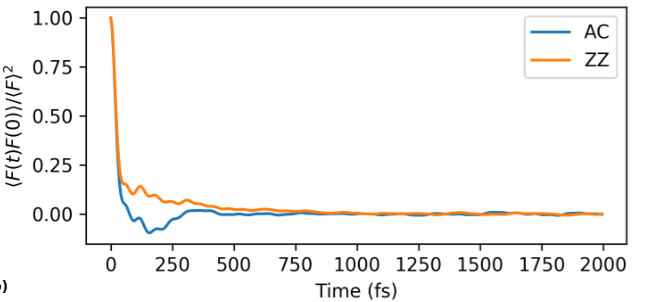

En la siguiente figura, se presenta la integral cumulativa de las ACF presentadas en la figura anterior. En ambas se logra un plateau para tiempos mayores a $1000$ fs. El valor de $\lambda$ calculado corresponderá al valor promedio logrado en este plateau. Para el caso ZZ, $\lambda=1.37\times 10^4$ Ns/m$^3$. Para el caso AC,  $\lambda=0.29\times 10^4$ Ns/m$^3$

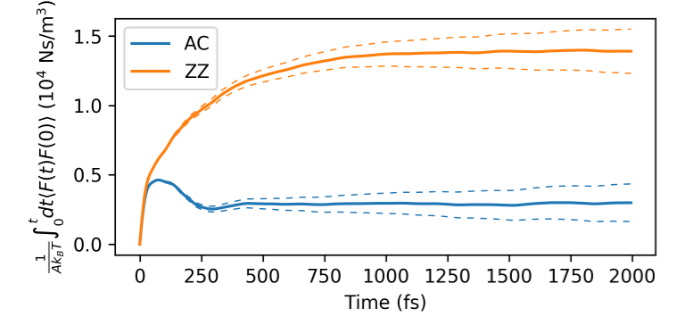